In [111]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.psd import aLIGOZeroDetHighPower
from simple_pe.waveforms import make_waveform
from pycbc.filter.matchedfilter import matched_filter
import warnings
import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)

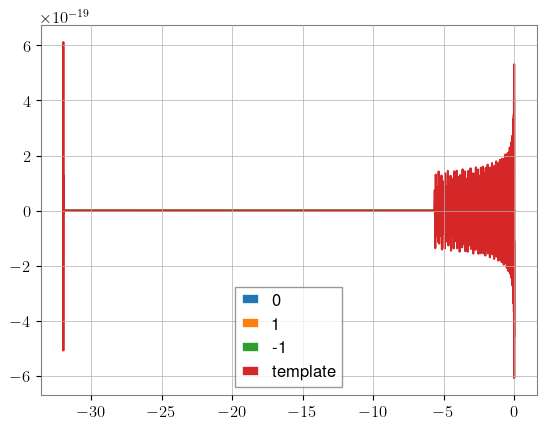

In [112]:
# Generate harmonics, template, psd
psd = aLIGOZeroDetHighPower(int(32*4096)//2 + 1, 1/32, 10)
params = {'chirp_mass': 24, 'symmetric_mass_ratio': 2/9, 'chi_align': 0, 'ecc10sqrd': 0.2**2}
harms = make_waveform(params, 1/32, 10, int(32*4096)//2 + 1, 'TEOBResumS-Dali-Harms', n_ecc_harms=3, ecc_harm_psd=psd)
template = make_waveform(params, 1/32, 10, int(32*4096)//2 + 1, 'TEOBResumS-Dali')

# Make plot
for i in harms.keys():
    h_ts = harms[i].to_timeseries()
    plt.plot(h_ts.sample_times, h_ts, label=str(i))
temp_ts = template.to_timeseries()
plt.plot(temp_ts.sample_times, temp_ts, label='template')
plt.legend()
plt.show()

In [113]:
def calculate_mode_snr(strain_data, ifo_psd, waveform_modes, t_start, t_end,
                       f_low, modes, dominant_mode=0,
                       subsample_interpolation=True):

    if dominant_mode not in waveform_modes.keys():
        print("Please give the waveform for the dominant mode")
        return

    s = matched_filter(waveform_modes[dominant_mode], strain_data, ifo_psd,
                       low_frequency_cutoff=f_low)
    plt.plot(s.sample_times, np.abs(s), label='before crop')
    snr = s.crop(t_start - s.start_time, s.end_time - t_end)
    plt.plot(snr.sample_times, np.abs(snr), label='after crop')
    plt.legend()
    plt.show()

    # find the peak and use this for the other modes later
    i_max = snr.abs_arg_max()
    t_max = snr.sample_times[i_max]
    if subsample_interpolation:
        from pycbc.filter.matchedfilter import quadratic_interpolate_peak
        # protect against peak being at the start of the timeseries
        left = abs(snr[-1]) if i_max == 0 else abs(snr[i_max - 1])
        middle = abs(snr[i_max])
        # protect against peak being at the end of the timeseries
        right = abs(snr[0]) if i_max == (len(snr) - 1) else abs(snr[i_max + 1])
        print(left, middle, right)
        id_shift, maxsnr = quadratic_interpolate_peak(left, middle, right)
        t_max += id_shift * snr.delta_t
    z = {}
    for mode in modes:
        s = matched_filter(
            waveform_modes[mode], strain_data, psd=ifo_psd,
            low_frequency_cutoff=f_low,
            high_frequency_cutoff=ifo_psd.sample_frequencies[-1],
            sigmasq=None
            )
        snr_ts = s.crop(t_start - s.start_time, s.end_time - t_end)

        if subsample_interpolation:
            try:
                z[mode] = snr_ts.at_time(t_max, interpolate='quadratic')
            except Exception as e:
                warnings.warn(
                    f"PyCBC snr interpolation failed for mode {mode} with"
                    f" error: {e}. Falling back to index-based snr peak."
                )
                z[mode] = snr_ts[i_max]
        else:
            z[mode] = snr_ts[i_max]

    return z, t_max


searching for peak on whole range


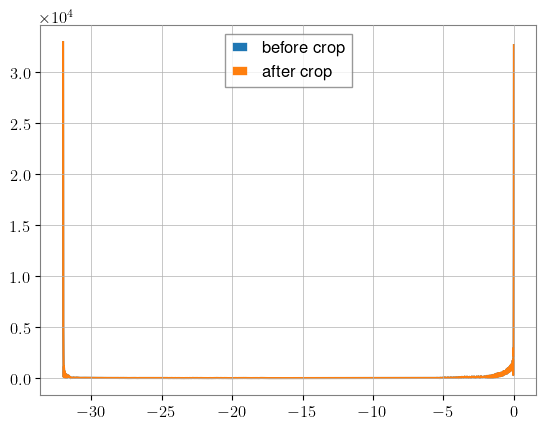

32668.47764902058 32966.235575974504 32936.21613087203
[(0, 32992.11084153291), (1, 7036.217408599544), (-1, 2435.4967841365524)] -31.999656148272738

searching for peak with crop


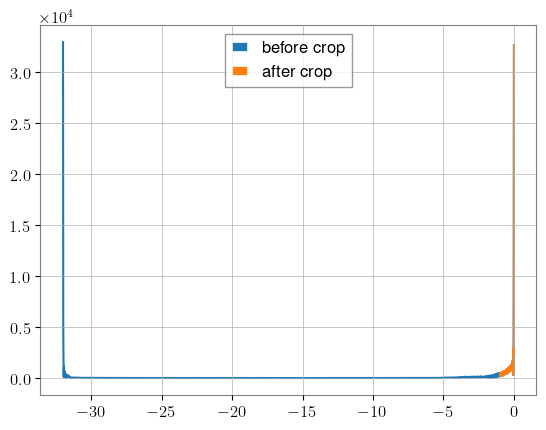

32056.338573609588 32668.47764902058 371.85743949375114
[(0, 32403.901452936963), (1, 7622.934042976398), (-1, 1089.9241806660136)] -0.00011752840366837694

searching for peak with crop, without subsample_interpolation


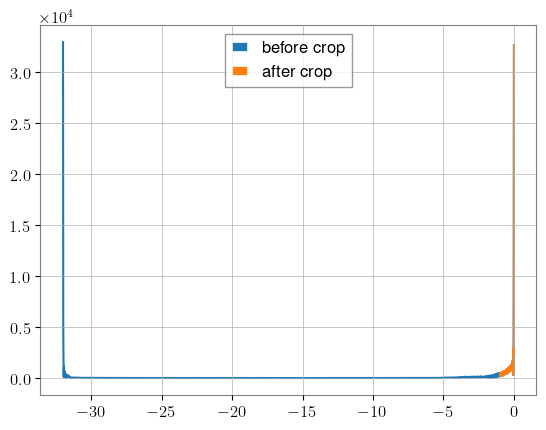

[(0, 32668.47764902058), (1, 7498.676770827605), (-1, 1296.6704475626282)] 6.250000517127319e-10


In [4]:
print('\nsearching for peak on whole range')
z, t = calculate_mode_snr(template, psd, harms, temp_ts.sample_times[0], temp_ts.sample_times[-1]+(temp_ts.sample_times[1]-temp_ts.sample_times[0]), 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)
print('\nsearching for peak with crop')
z, t = calculate_mode_snr(template, psd, harms, -1, 1, 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)
print('\nsearching for peak with crop, without subsample_interpolation')
z, t = calculate_mode_snr(template, psd, harms, -1, 1, 20, [0, 1, -1], subsample_interpolation=False)
print([(i, np.abs(z[i])) for i in z.keys()], t)

The subsample interpolation breaks down when a limiting t_start/t_end is provided as it incorrectly cuts off the peak in snr at the start of the timeseries.

In [114]:
def calculate_mode_snr_fixed(strain_data, ifo_psd, waveform_modes, t_start, t_end,
                             f_low, modes, dominant_mode=0,
                             subsample_interpolation=True):

    if dominant_mode not in waveform_modes.keys():
        print("Please give the waveform for the dominant mode")
        return

    time_shift = t_start - strain_data.start_time
    # tmp_modes = {i: waveform_modes[i].copy() for i in modes}
    # tmp_modes = {i: tmp_modes[i].cyclic_time_shift(-time_shift) for i in modes}
    tmp_strain = strain_data.copy().cyclic_time_shift(-time_shift)

    s = matched_filter(waveform_modes[dominant_mode], tmp_strain, ifo_psd,
                       low_frequency_cutoff=f_low)
    plt.plot(s.sample_times, np.abs(s), label='before crop')
    snr = s.crop(t_start - s.start_time, s.end_time - t_end)
    plt.plot(snr.sample_times, np.abs(snr), label='after crop')
    plt.legend()
    plt.show()

    # find the peak and use this for the other modes later
    i_max = snr.abs_arg_max()
    t_max = snr.sample_times[i_max]
    if subsample_interpolation:
        from pycbc.filter.matchedfilter import quadratic_interpolate_peak
        # protect against peak being at the start of the timeseries
        left = abs(snr[-1]) if i_max == 0 else abs(snr[i_max - 1])
        middle = abs(snr[i_max])
        # protect against peak being at the end of the timeseries
        right = abs(snr[0]) if i_max == (len(snr) - 1) else abs(snr[i_max + 1])
        print(left, middle, right)
        id_shift, maxsnr = quadratic_interpolate_peak(left, middle, right)
        t_max += id_shift * snr.delta_t
    z = {}
    for mode in modes:
        s = matched_filter(
            waveform_modes[mode], tmp_strain, psd=ifo_psd,
            low_frequency_cutoff=f_low,
            high_frequency_cutoff=ifo_psd.sample_frequencies[-1],
            sigmasq=None
            )
        snr_ts = s.crop(t_start - s.start_time, s.end_time - t_end)

        if subsample_interpolation:
            try:
                z[mode] = snr_ts.at_time(t_max, interpolate='quadratic')
            except Exception as e:
                warnings.warn(
                    f"PyCBC snr interpolation failed for mode {mode} with"
                    f" error: {e}. Falling back to index-based snr peak."
                )
                z[mode] = snr_ts[i_max]
        else:
            z[mode] = snr_ts[i_max]

    delta_t = 1/(len(strain_data)*strain_data.delta_f)
    end_time = strain_data.start_time + 1/strain_data.delta_f - delta_t
    print(end_time)
    if t_max > end_time:
        t_max -= strain_data.duration

    return z, t_max


searching for peak on whole range


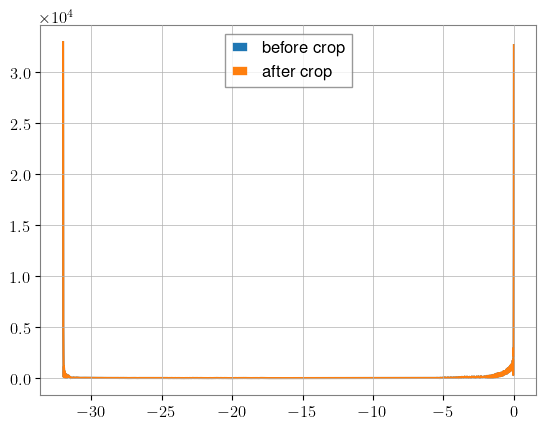

32668.47764902058 32966.235575974504 32936.21613087203
-0.000244133
[(0, 32992.11084153291), (1, 7036.217408599544), (-1, 2435.4967841365524)] -31.999656148272738

searching for peak with crop


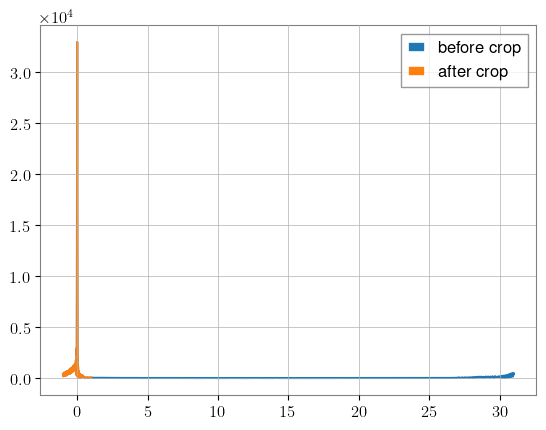

32668.473531998487 32966.23436372438 32936.21788175405
-0.000244133
[(0, 32992.11078674607), (1, 7036.217421931956), (-1, 2435.4967352988765)] -31.999656146444668

searching for peak with crop, without subsample_interpolation


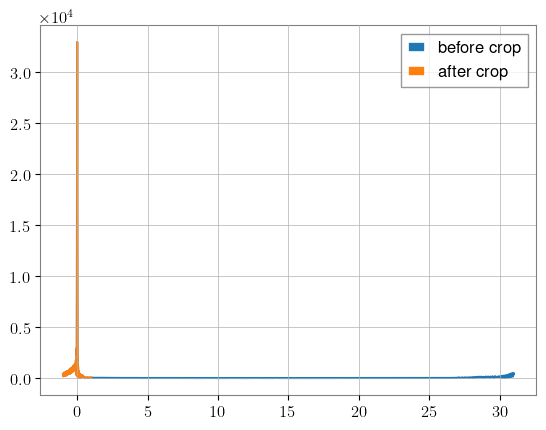

-0.000244133
[(0, 32966.23436372438), (1, 7183.368379613213), (-1, 2075.579376839556)] -31.999755859375


In [5]:
print('\nsearching for peak on whole range')
z, t = calculate_mode_snr_fixed(template, psd, harms, temp_ts.sample_times[0], temp_ts.sample_times[-1]+(temp_ts.sample_times[1]-temp_ts.sample_times[0]), 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)
print('\nsearching for peak with crop')
z, t = calculate_mode_snr_fixed(template, psd, harms, -1, 1, 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)
print('\nsearching for peak with crop, without subsample_interpolation')
z, t = calculate_mode_snr_fixed(template, psd, harms, -1, 1, 20, [0, 1, -1], subsample_interpolation=False)
print([(i, np.abs(z[i])) for i in z.keys()], t)

This now recovers the correct snrs and times.

What about when time spans full range? We sometimes get 'PyCBC snr interpolation failed' errors, as below.

In [15]:
params = {'chirp_mass': 35, 'symmetric_mass_ratio': 2/9, 'chi_align': 0, 'ecc10sqrd': 0.2**2}
harms3 = make_waveform(params, 1/32, 10, int(32*4096)//2 + 1, 'TEOBResumS-Dali-Harms', n_ecc_harms=3, ecc_harm_psd=psd)
template3 = make_waveform(params, 1/32, 10, int(32*4096)//2 + 1, 'TEOBResumS-Dali')
temp3_ts = template3.to_timeseries()

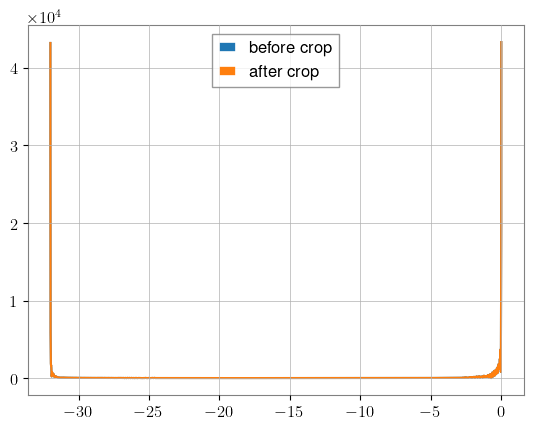

43182.101699526465 43303.194075240324 43193.34487410522


/tmp/ipykernel_1296/436735487.py:49: UserWarning: PyCBC snr interpolation failed for mode 0 with error: index 131072 is out of bounds for axis 0 with size 131072. Falling back to index-based snr peak.
  warnings.warn(
/tmp/ipykernel_1296/436735487.py:49: UserWarning: PyCBC snr interpolation failed for mode 1 with error: index 131072 is out of bounds for axis 0 with size 131072. Falling back to index-based snr peak.
  warnings.warn(


-0.000244133
[(0, 43303.194075240324), (1, 10307.575483318058), (-1, 4592.851481261049)] -31.999994056746058


/tmp/ipykernel_1296/436735487.py:49: UserWarning: PyCBC snr interpolation failed for mode -1 with error: index 131072 is out of bounds for axis 0 with size 131072. Falling back to index-based snr peak.
  warnings.warn(


In [40]:
z, t = calculate_mode_snr_fixed(template3, psd, harms3, temp3_ts.start_time, temp3_ts.end_time, 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)

In [115]:
def calculate_mode_snr_fixed2(strain_data, ifo_psd, waveform_modes, t_start, t_end,
                              f_low, modes, dominant_mode=0,
                              subsample_interpolation=True):

    if dominant_mode not in waveform_modes.keys():
        print("Please give the waveform for the dominant mode")
        return

    time_shift = t_start - strain_data.start_time
    # tmp_modes = {i: waveform_modes[i].copy() for i in modes}
    # tmp_modes = {i: tmp_modes[i].cyclic_time_shift(-time_shift) for i in modes}
    tmp_strain = strain_data.copy().cyclic_time_shift(-time_shift)

    s = matched_filter(waveform_modes[dominant_mode], tmp_strain, ifo_psd,
                       low_frequency_cutoff=f_low)
    plt.plot(s.sample_times, np.abs(s), label='before crop')
    snr = s.crop(t_start - s.start_time, s.end_time - t_end)
    plt.plot(snr.sample_times, np.abs(snr), label='after crop')
    plt.legend()
    plt.show()

    # find the peak and use this for the other modes later
    i_max = snr.abs_arg_max()
    t_max = snr.sample_times[i_max]
    if subsample_interpolation:
        from pycbc.filter.matchedfilter import quadratic_interpolate_peak
        # protect against peak being at the start of the timeseries
        left = abs(snr[-1]) if i_max == 0 else abs(snr[i_max - 1])
        middle = abs(snr[i_max])
        # protect against peak being at the end of the timeseries
        right = abs(snr[0]) if i_max == (len(snr) - 1) else abs(snr[i_max + 1])
        print(left, middle, right)
        id_shift, maxsnr = quadratic_interpolate_peak(left, middle, right)
        t_max += id_shift * snr.delta_t
        if t_max > snr.sample_times[-1]:
            time_shift += snr.delta_t
            t_start += snr.delta_t
            t_end += snr.delta_t
            tmp_strain = strain_data.copy().cyclic_time_shift(-time_shift)
        print(tmp_strain.to_timeseries().sample_times[-3:], t_max)
    z = {}
    for mode in modes:
        s = matched_filter(
            waveform_modes[mode], tmp_strain, psd=ifo_psd,
            low_frequency_cutoff=f_low,
            high_frequency_cutoff=ifo_psd.sample_frequencies[-1],
            sigmasq=None
            )
        snr_ts = s.crop(t_start - s.start_time, s.end_time - t_end)
        print(snr_ts.sample_times[-3:], t_max)

        if subsample_interpolation:
            try:
                z[mode] = snr_ts.at_time(t_max, interpolate='quadratic')
            except Exception as e:
                warnings.warn(
                    f"PyCBC snr interpolation failed for mode {mode} with"
                    f" error: {e}. Falling back to index-based snr peak."
                )
                z[mode] = snr_ts[i_max]
        else:
            z[mode] = snr_ts[i_max]

    delta_t = 1/(len(strain_data)*strain_data.delta_f)
    end_time = strain_data.start_time + 1/strain_data.delta_f - delta_t
    print(end_time)
    while t_max > end_time:
        t_max -= strain_data.duration

    return z, t_max

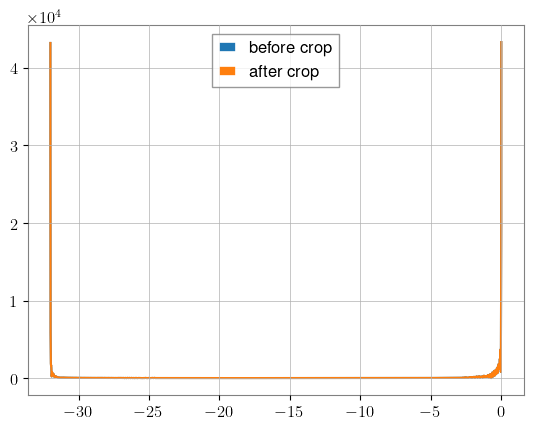

43182.101699526465 43303.194075240324 43193.34487410522
[-2.44139875e-04  7.49999174e-10  2.44141375e-04] 5.943253943460255e-06
[-2.44139875e-04  7.49999174e-10  2.44141375e-04] 5.943253943460255e-06
[-2.44139875e-04  7.49999174e-10  2.44141375e-04] 5.943253943460255e-06
[-2.44139875e-04  7.49999174e-10  2.44141375e-04] 5.943253943460255e-06
-0.000244133
[(0, 43303.231709298336), (1, 10297.774222279662), (-1, 4619.489591213228)] -31.999994056746058


In [41]:
z, t = calculate_mode_snr_fixed2(template3, psd, harms3, temp3_ts.start_time, temp3_ts.end_time, 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)

This fixes this error as well.

In [116]:
from pycbc import frame
H1_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/tests/choose_ncpus/outdir/output/H1-INJECTION.gwf'
data = frame.read_frame(H1_path, 'H1:HWINJ_INJECTED', 1677672000-16, 1677672000+16)

(1677671999.9, 1677672000.1)

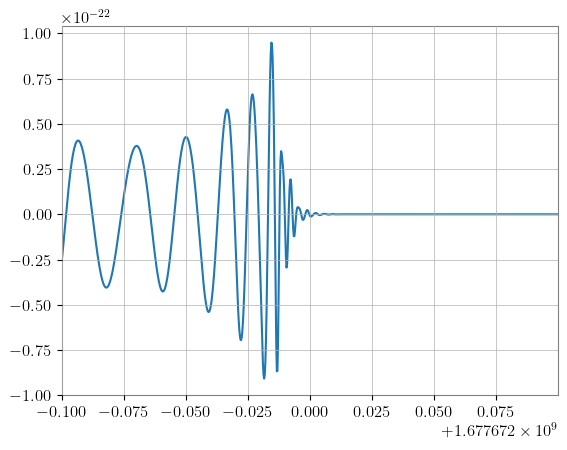

In [117]:
plt.plot(data.sample_times, data)
plt.xlim(1677672000-0.1, 1677672000+0.1)

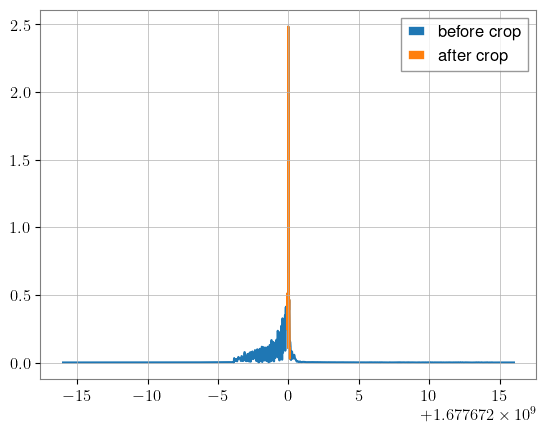

2.4810358671899304 2.484344176088124 2.470336316362082
[(0, 2.485825308888069), (1, 0.06723213715084314), (-1, 1.5655672499467828)] 1677671999.9860086


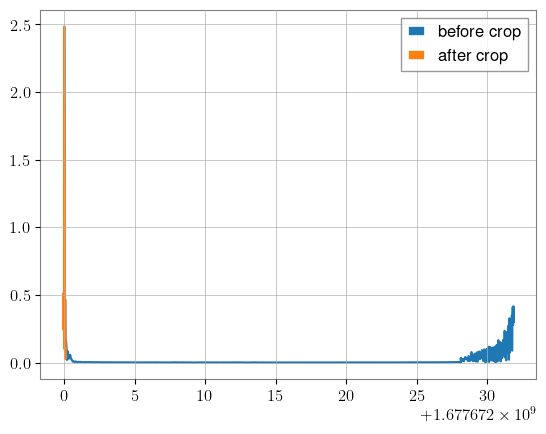

2.469790136144468 2.484598810206806 2.4806641874350626
[1.67767203e+09 1.67767203e+09 1.67767203e+09] 1677671999.9860084
[1.677672e+09 1.677672e+09 1.677672e+09] 1677671999.9860084
[1.677672e+09 1.677672e+09 1.677672e+09] 1677671999.9860084
[1.677672e+09 1.677672e+09 1.677672e+09] 1677671999.9860084
1677672015.999755859
[(0, 2.4857770618260924), (1, 0.06717952611898138), (-1, 1.5654784368190577)] 1677671999.9860084


In [118]:
t_start = 1677672000 - 0.1
t_end = 1677672000 + 0.1

z, t = calculate_mode_snr(data, psd, harms, t_start, t_end, 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)
z, t = calculate_mode_snr_fixed2(data, psd, harms, t_start, t_end, 20, [0, 1, -1])
print([(i, np.abs(z[i])) for i in z.keys()], t)

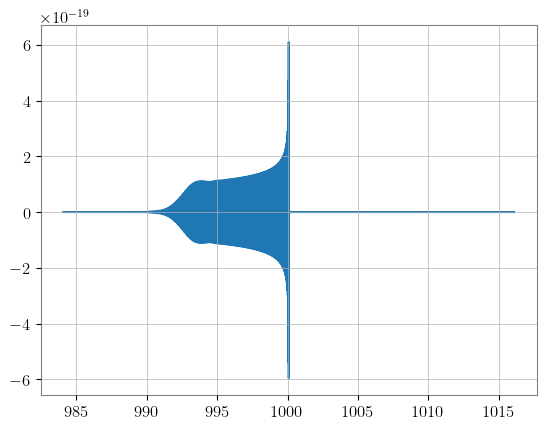

In [121]:
params = {'chirp_mass': 24, 'symmetric_mass_ratio': 2/9, 'chi_align': 0}
template = make_waveform(params, 1/32, 10, int(32*4096)//2 + 1, 'IMRPhenomXPHM')
template.start_time += 1000
template_shift = template.cyclic_time_shift(-16)
temp_ts = template_shift.to_timeseries()
t_start = 1000-1
t_end = 1000+1
plt.plot(temp_ts.sample_times, temp_ts)

In [11]:
data_dict = {'H1': template_shift}
psd_dict = {'H1': psd}
from simple_pe.param_est import find_peak_snr
from simple_pe import waveforms

x = {'chirp_mass': 23.5, 'symmetric_mass_ratio': 0.22, 'chi_align': 0.05}
mins = waveforms.parameter_bounds.param_mins
maxs = waveforms.parameter_bounds.param_maxs
bounds = [(10, 30), (0.15, 0.2499), (-0.3, 0.3)]
peak = find_peak_snr(
            ['H1'], data_dict, psd_dict, t_start, t_end, x, ['chirp_mass', 'symmetric_mass_ratio', 'chi_align'], 20,
            approximant="IMRPhenomXPHM", method='scipy', scipy_method=None, bounds=bounds
        )
print(peak)

({'chirp_mass': 23.999905348226942, 'symmetric_mass_ratio': 0.22223478990368054, 'chi_align': -6.296870752183148e-05}, 33468.068458386864)


In [10]:
# Edited neg_net_snr to randomly add snr between -10**-4 and 10**-4
data_dict = {'H1': template_shift}
psd_dict = {'H1': psd}
from simple_pe.param_est import find_peak_snr
from simple_pe import waveforms

x = {'chirp_mass': 23.5, 'symmetric_mass_ratio': 0.22, 'chi_align': -0.25}
mins = waveforms.parameter_bounds.param_mins
maxs = waveforms.parameter_bounds.param_maxs
bounds = [(10, 30), (0.15, 0.2499), (-0.3, 0.3)]
peak = find_peak_snr(
            ['H1'], data_dict, psd_dict, t_start, t_end, x, ['chirp_mass', 'symmetric_mass_ratio', 'chi_align'], 20,
            approximant="IMRPhenomXPHM", method='scipy', scipy_method=None, bounds=bounds
        )
print(peak)

({'chirp_mass': 22.350130520397123, 'symmetric_mass_ratio': 0.21521146099188912, 'chi_align': -0.2019156661426215}, 32451.784450867068)
